In [4]:
# generate dataset
import pandas as pd
import numpy as np

np.random.seed(42)
n= 500
data = {
     "Customer_ID": range(1, n+1),
    "Age": np.random.randint(21, 60, n),
    "Income": np.random.randint(20000, 150000, n),
    "Loan_Amount": np.random.randint(50000, 1000000, n),
    "Credit_Score": np.random.randint(300, 850, n),
    "Loan_Term": np.random.choice([12,24,36,48,60], n)
}
df = pd.DataFrame(data)

df["Default_Status"] = np.where(
    (df["Credit_Score"] < 600) &
    (df["Loan_Amount"] > 500000),
    "Yes",
    "No"
)
df.to_csv("loan_applications.csv", index=False)
print("Dataset Created Successfully")

Dataset Created Successfully


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import stats
from numpy.linalg import norm as vector_norm

In [7]:
# load dataset
df = pd.read_csv("loan_applications.csv")
print(df.head())

   Customer_ID  Age  Income  Loan_Amount  Credit_Score  Loan_Term  \
0            1   59  104076       806254           775         48   
1            2   49  109780       840756           429         24   
2            3   35   41545       912755           662         48   
3            4   28   41689       845543           591         60   
4            5   41   31174       590677           670         24   

  Default_Status  
0             No  
1            Yes  
2             No  
3            Yes  
4             No  


In [8]:
# Mean, Median, Mode
print("Mean Income =", df["Income"].mean())
print("Median Income =", df["Income"].median())
print("Mode Income =", df["Income"].mode()[0])

Mean Income = 82915.798
Median Income = 79446.5
Mode Income = 20055


In [9]:
# range, variance, standard deviation
print("Range =", df["Loan_Amount"].max() - df["Loan_Amount"].min())
print("Variance =", df["Loan_Amount"].var())
print("Std Dev =", df["Loan_Amount"].std())

Range = 947901
Variance = 80185292594.9569
Std Dev = 283170.0771532135


In [10]:
# Probability of Default
p_default = (df["Default_Status"]=="Yes").mean()
print("Probability of Default =", p_default)

Probability of Default = 0.27


In [11]:
# contingency table
df["Credit_Range"] = pd.cut(
    df["Credit_Score"],
    bins=[300,600,700,850],
    labels=["Low","Medium","High"]
)

table = pd.crosstab(
    df["Credit_Range"],
    df["Default_Status"]
)

print(table)

Default_Status   No  Yes
Credit_Range            
Low             136  135
Medium          107    0
High            121    0


In [12]:
# Conditional Probability
low_credit = df[df["Credit_Score"] < 600]

conditional_prob = (
    low_credit["Default_Status"]=="Yes"
).mean()

print("P(Default | Credit Score < 600) =",
      conditional_prob)

P(Default | Credit Score < 600) = 0.503731343283582


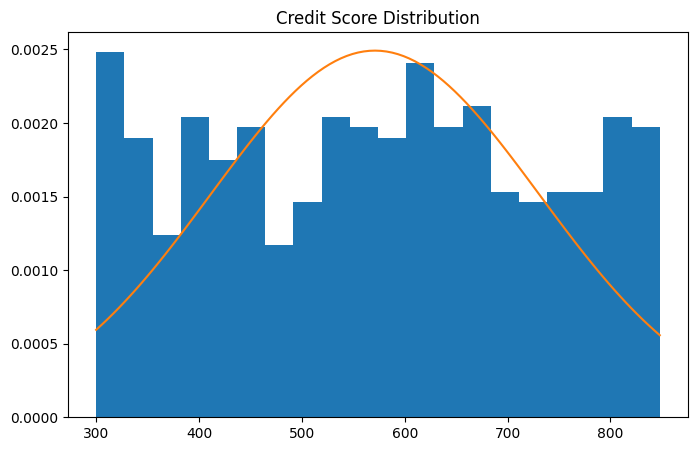

In [13]:
# histogram + gaussian curve
x = df["Credit_Score"]

plt.figure(figsize=(8,5))

plt.hist(
    x,
    bins=20,
    density=True
)

mu = x.mean()
sigma = x.std()

line = np.linspace(
    x.min(),
    x.max(),
    100
)

plt.plot(
    line,
    norm.pdf(line,mu,sigma)
)

plt.title("Credit Score Distribution")
plt.show()

In [15]:
# skewness and kurtosis
print("Skewness =",
      df["Loan_Amount"].skew())

print("Kurtosis =",
      df["Loan_Amount"].kurt())

Skewness = 0.04647174011467382
Kurtosis = -1.2521224817465353


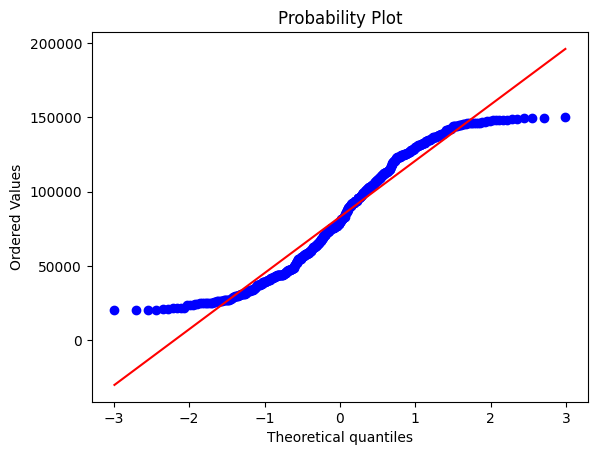

In [17]:
# Q-Q plot
stats.probplot(
    df["Income"],
    dist="norm",
    plot=plt
)

plt.show()

In [20]:
# linear algebra
# first 5 customer
vectors = df[
    ["Income","Loan_Amount"]
].head()

print(vectors)

   Income  Loan_Amount
0  104076       806254
1  109780       840756
2   41545       912755
3   41689       845543
4   31174       590677


In [21]:
# Dot product
v1 = vectors.iloc[0].values
v2 = vectors.iloc[1].values

dot_product = np.dot(v1,v2)

print("Dot Product =", dot_product)

Dot Product = 689288351304


In [22]:
# norm
norm_value = vector_norm(v1)
print("Norm =", norm_value)

Norm = 812943.61815073


In [23]:
# angle between vectors
angle = np.degrees(
    np.arccos(
        np.dot(v1,v2)
        /
        (
           vector_norm(v1)
            *
            vector_norm(v2)
        )
    )
)

print("Angle =", angle)  

Angle = 0.08379156405367026


In [ ]:
# final insights
1.customer with low credit scores are more likely to default on loans compared to customers with credit scores.
2.Credit Score is one of the most important factors in assessing loan repayment risk.
3.The Loan Amount data shows significant variation, indicating that customers borrow different amounts based on their financial requirements.
4.The Income distribution is approximately normal, suggesting a balanced spread of customer income levels.
5.Conditional Probability analysis shows that the probability of default increases when the credit score is below 600.
6.Statistical measures such as Mean, Median, Mode, Variance, and Standard Deviation help in understanding customer financial behavior.
7.Linear Algebra concepts such as Dot Product, Norm, and Angle Between Vectors can be applied to represent and analyze customer data mathematically.   